In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import uniform

In [3]:
def calc_T(today):
    '''
    probability of transition given the current value
    c = cloudy
    s = sunny
    '''

    if today == 'c':
        p_cloud = 0.5
        p_sun = 0.5

    elif today == 's':
        p_cloud = 0.1
        p_sun = 0.9

    return p_cloud, p_sun #the prob. of cloud and sun tomorrow

In [35]:
def extract_weather(today):
    
    p_cloud, p_sun = calc_T(today)
    num = uniform.rvs(loc=0, scale=1)
    
    if today == 'c':
        '''
        if today it's cloudy, there is an equal prob of today being either weather
        so I just take the value that has been just extracted to decide the weather
        '''
        extr = round(num) #0 = sun, 1 = cloud

    else:
        '''
        if today it's sunny, there is a higher probability that tomorrow will be sunny again.
        so it will be sunny if 1-num is < 0.9 (very likely) and cloudy if 1-num >= 0.9 (10% of times)
        '''
        if (1-num) < p_sun:
            extr = 0
        else:
            extr = 1

    if extr == 1:
        w = 'c'

    else:
        w = 's'

    return w

In [36]:
start = 'c'
N = 10000
days_weather = [start]

for i in range(N):
    tomorrow = extract_weather(days_weather[i])
    days_weather.append(tomorrow)

In [42]:
def cum_days_weat(days):
    cloud = 0
    sun = 0

    cloud_cum = []
    sun_cum = []
    n = len(days)
    
    for i in range(n-1):
        
        if days[i] == 'c':
            cloud += 1
        else:
            sun += 1

        n_days_now = i+1

        frac_cloud = cloud/n_days_now
        frac_sun = sun/n_days_now

        cloud_cum.append(frac_cloud)
        sun_cum.append(frac_sun)

    return cloud_cum, sun_cum

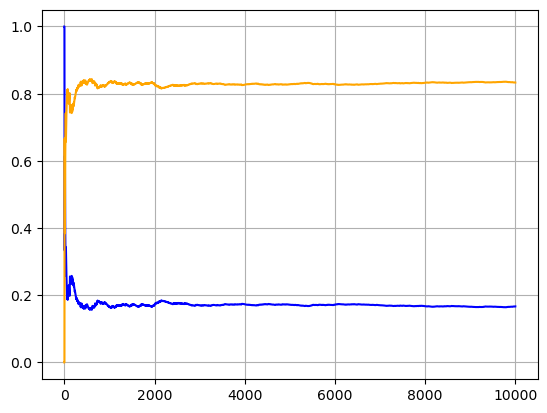

In [43]:
fig, ax = plt.subplots()

cloud_cum, sun_cum = cum_days_weat(days_weather)
xarr = np.arange(0, N)
plt.plot(xarr, cloud_cum, color='blue')
plt.plot(xarr, sun_cum, color='orange')
plt.grid()